# Plot figures of results

Import requisites

In [1]:
import glob
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import yaml
import seaborn as sns
import io
import os
import warnings

from PIL import Image
from tensorboard.backend.event_processing import event_accumulator
from typing import Union
from rliable import library as rly, metrics as rl_metrics

In [2]:
MULTI_SEGMENT_CONFIG_DEMAND = '../configs/rl/demand_data_base.yaml'
MULTI_SEGMENT_CONFIG_SUPPLY = '../configs/rl/supply_data_base.yaml'
EXTENDED_CONFIG_DEMAND = '../configs/rl/demand_data_large.yaml'
EXTENDED_CONFIG_SUPPLY = '../configs/rl/supply_data_large.yaml'

MULTI_SEGMENT_EPISODE_LENGTH = 7

MULTI_SEGMENT_RANDOM_SCORE = 30946
MULTI_SEGMENT_RANDOM_AGENT1_SCORE = 10964
MULTI_SEGMENT_RANDOM_AGENT2_SCORE = 9545
MULTI_SEGMENT_RANDOM_AGENT3_SCORE = 10437

MULTI_SEGMENT_STATIC_SCORE = 31340
MULTI_SEGMENT_STATIC_AGENT1_SCORE = 11188
MULTI_SEGMENT_STATIC_AGENT2_SCORE = 9717
MULTI_SEGMENT_STATIC_AGENT3_SCORE = 10434

EXTENDED_EPISODE_LENGTH = 10

EXTENDED_RANDOM_SCORE = 39977
EXTENDED_RANDOM_AGENT1_SCORE = 13641
EXTENDED_RANDOM_AGENT2_SCORE = 11483
EXTENDED_RANDOM_AGENT3_SCORE = 8523
EXTENDED_RANDOM_AGENT4_SCORE = 6329

EXTENDED_STATIC_SCORE = 40933
EXTENDED_STATIC_AGENT1_SCORE = 13975
EXTENDED_STATIC_AGENT2_SCORE = 11559
EXTENDED_STATIC_AGENT3_SCORE = 8900
EXTENDED_STATIC_AGENT4_SCORE = 6498

MIN_TIMESTEPS = 0
MAX_TIMESTEPS = 1_000_000

REPORTS_PATH = '../reports'
MODELS_PATH = '../models/paper'

os.makedirs(REPORTS_PATH, exist_ok=True)
warnings.filterwarnings('ignore')

Figures style

In [3]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 14

plt.rc('font', size=BIGGER_SIZE, family='serif')   # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE - 2)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)   # fontsize of the figure title

## Code for plotting results

### Processing

In [4]:
def load_statistics_from_tensorboard(paths: list[list[str]], tags: list[str], evaluation: bool) -> dict[str, list[pd.DataFrame]]:
    df_metrics: dict[str, list[pd.DataFrame]] = {}
    tags_pattern = [re.compile(tag) for tag in tags]
    for exchange_paths in paths:
        df_metric: dict[str, pd.DataFrame] = {}
        for execution_num, path in enumerate(exchange_paths):
            files = glob.glob(path, recursive=True)
            for file in files:
                if 'events.out.tfevents' not in file:
                    continue
                if not evaluation and any([x in file for x in ['evaluation', 'test']]):
                    continue
                if evaluation and all([x not in file for x in ['evaluation', 'test']]):
                    continue
                print(f'Loading {file}')
                ea = event_accumulator.EventAccumulator(path=file)
                ea.Reload()
                all_tags = ea.Tags()
                _tags = []
                for pattern in tags_pattern:
                    matched_tags = list(filter(pattern.match, all_tags['scalars']))
                    _tags.extend(matched_tags)
                for tag in _tags:
                    if tag not in df_metric:
                        df_metric[tag] = pd.DataFrame()
                    try:
                        _df_metric = pd.DataFrame(ea.Scalars(tag))
                        _df_metric['execution_num'] = execution_num
                        df_metric[tag] = pd.concat([df_metric[tag], _df_metric], axis=0)
                    except KeyError:
                        pass
        for tag in df_metric:
            if tag not in df_metrics:
                df_metrics[tag] = []
            if not df_metric[tag].empty:
                df_metrics[tag].append(df_metric[tag].sort_values(by=['step', 'execution_num']))
    return df_metrics

In [5]:
def load_images_from_tensorboard(paths: list[list[str]], tags: list[str], evaluation: bool) -> dict[str, list[pd.DataFrame]]:
    image_metrics = {tag: [] for tag in tags}
    for exchange_paths in paths:
        image_metric = {tag: pd.DataFrame() for tag in tags}
        for execution_num, path in enumerate(exchange_paths):
            files = glob.glob(path, recursive=True)
            for file in files:
                if 'events.out.tfevents' not in file:
                    continue
                if not evaluation and any([x in file for x in ['evaluation', 'test']]):
                    continue
                if evaluation and all([x not in file for x in ['evaluation', 'test']]):
                    continue
                if 'graph_matd3' not in file:
                    continue
                print(f'Loading {file}')
                ea = event_accumulator.EventAccumulator(path=file, size_guidance={event_accumulator.IMAGES: 0})
                ea.Reload()
                for tag in tags:
                    try:
                        image_events = ea.Images(tag)
                        rows = []
                        for event in image_events:
                            img = Image.open(io.BytesIO(event.encoded_image_string))
                            img_array = np.array(img)
                            rows.append({
                                'step': event.step,
                                'wall_time': event.wall_time,
                                'execution_num': execution_num,
                                'image': img_array
                            })
                        _df_metric = pd.DataFrame(rows)
                        image_metric[tag] = pd.concat([image_metric[tag], _df_metric], axis=0)
                    except KeyError:
                        pass
        for tag in tags:
            if not image_metric[tag].empty:
                image_metrics[tag].append(image_metric[tag].sort_values(by=['step', 'execution_num']))
    return image_metrics

In [6]:
def to_normalized_score(df_results: dict[str, list[pd.DataFrame]], scenario: str) -> dict[str, list[pd.DataFrame]]:
    for tag in df_results.keys():
        for i in range(len(df_results[tag])):
            if scenario == 'Multi-Segment':
                df_results[tag][i].value = (np.array(df_results[tag][i].value) - MULTI_SEGMENT_RANDOM_SCORE) * 100 / MULTI_SEGMENT_RANDOM_SCORE
            elif scenario == 'Extended':
                df_results[tag][i].value = (np.array(df_results[tag][i].value) - EXTENDED_RANDOM_SCORE) * 100 / EXTENDED_RANDOM_SCORE
    return df_results

In [7]:
def to_timesteps(df_results: dict[str, list[pd.DataFrame]], scenario: str) -> dict[str, list[pd.DataFrame]]:
    for tag in df_results.keys():
        for i in range(len(df_results[tag])):
            if scenario == 'Multi-Segment':
                df_results[tag][i].step = df_results[tag][i].step * MULTI_SEGMENT_EPISODE_LENGTH
            elif scenario == 'Extended':
                df_results[tag][i].step = df_results[tag][i].step * EXTENDED_EPISODE_LENGTH
    return df_results

In [8]:
def downsample(df_results: dict[str, list[pd.DataFrame]]) -> dict[str, list[pd.DataFrame]]:
    for tag in df_results.keys():
        df_results[tag] = [df.groupby('execution_num').apply(lambda x: x.iloc[::100]).reset_index(drop=True).sort_values(by=['step', 'execution_num']).reset_index(drop=True) for df in df_results[tag]]
    return df_results

In [9]:
def preprocess_data(logs: list[str], tags: list[str], scenario: str, evaluation: bool) -> list[pd.DataFrame]:
    df_results = load_statistics_from_tensorboard(logs, tags, evaluation)
    df_results = to_timesteps(df_results, scenario)
    df_results = downsample(df_results)
    #df_results = to_normalized_score(df_results, scenario)
    return df_results

In [10]:
def get_mean_std(df_results: list[pd.DataFrame], tag: str, index: list[str]) -> list[pd.DataFrame]:
    df_results = [df.groupby('execution_num')['value'].agg(['mean', 'std']).reset_index(drop=True) for df in df_results[tag]]
    mean_df_results = pd.DataFrame()
    mean_df_results['mean'] = np.array([df['mean'].mean() for df in df_results])
    mean_df_results['std'] = np.array([df['mean'].std() for df in df_results])
    mean_df_results.index = index
    return mean_df_results

In [11]:
def get_std_diff(df_results: list[pd.DataFrame], index: list[str]) -> list[pd.DataFrame]:
    keys = [key for key in df_results.keys() if 'agents/mean_profit' in key]
    df_std_diff = [df.groupby('execution_num')['value'].apply(lambda x: np.std(np.diff(x), ddof=1)).agg(['mean', 'std']) for tag in keys for df in df_results[tag]]
    df_std_diff = pd.DataFrame(df_std_diff)
    num_agents = df_std_diff.shape[0] // df_std_diff.shape[1]
    df_std_diff.index = [f'{name} (Agent {i + 1})' for i in range(num_agents) for name in index]
    return df_std_diff

In [12]:
def get_total_wall_time(df_results: list[pd.DataFrame], index: list[str]) -> list[pd.DataFrame]:
    df_results = [df for df in df_results['services/mean_total_profit']]
    df_total_wall_time = [df.groupby('execution_num')['wall_time'].agg(['first', 'last']).reset_index(drop=True) for df in df_results]
    df_total_wall_time = pd.DataFrame([df['last'] - df['first'] for df in df_total_wall_time])
    df_total_wall_time = df_total_wall_time.sum(axis=1) / 3600
    df_total_wall_time.index = index
    return df_total_wall_time

In [13]:
def get_score_matrix(df_results, tag, algorithms_evaluation):
    """Return {algo: ndarray(n_seeds, n_eval_steps)} for rliable."""
    score_dict = {}
    for i, algo in enumerate(algorithms_evaluation):
        df = df_results[tag][i]
        per_seed = [g['value'].to_numpy() for _, g in df.groupby('execution_num')]
        T = min(len(s) for s in per_seed)
        score_dict[algo] = np.stack([s[:T] for s in per_seed], axis=0)
    return score_dict

def get_bootstrap_ci_table(df_results, tag, algorithms, reps=50000, ci=0.95):
    """Bootstrap CI on the mean across seeds × evaluation steps."""
    score_dict = get_score_matrix(df_results, tag, algorithms)
    estimates, cis = rly.get_interval_estimates(
        score_dict, rl_metrics.aggregate_mean, reps=reps, confidence_interval_size=ci)
    rows = {
        algo: {
            'mean': float(estimates[algo]),
            f'CI_low': float(cis[algo].flatten()[0]),
            f'CI_high': float(cis[algo].flatten()[1]),
        }
        for algo in algorithms
    }
    df = pd.DataFrame(rows).T
    df.reset_index(inplace=True)
    return df

def get_prob_improvement(df_results, tag, algorithms, base='RACHE'):
    """P(base > each baseline) using rliable's probability_of_improvement."""
    score_dict = get_score_matrix(df_results, tag, algorithms)
    base_scores = score_dict[base]
    results = {}
    for algo in algorithms:
        if algo == base:
            continue
        p = float(rl_metrics.probability_of_improvement(base_scores, score_dict[algo]))
        results[algo] = {'P(RACHE > X)': round(p, 2)}
    return pd.DataFrame(results).T

def get_poi_matrix(df_results, tag, algorithms):
    """Full pairwise P(row > col) matrix using rliable's probability_of_improvement."""
    score_dict = get_score_matrix(df_results, tag, algorithms)
    n = len(algorithms)
    matrix = np.full((n, n), np.nan)
    for i, algo_i in enumerate(algorithms):
        for j, algo_j in enumerate(algorithms):
            if i != j:
                xi = score_dict[algo_i]
                xj = score_dict[algo_j]
                T = min(xi.shape[1], xj.shape[1])
                matrix[i, j] = float(rl_metrics.probability_of_improvement(xi[:, :T], xj[:, :T]))
    return pd.DataFrame(matrix, index=algorithms, columns=algorithms)

In [14]:
def get_df_agents(df_results: pd.DataFrame, tags: list[str], algorithms: list[str]) -> pd.DataFrame:
    df = pd.DataFrame()
    for agent_idx, tag in enumerate(tags):
        df_agent = get_bootstrap_ci_table(df_results, tag, algorithms)
        df_agent['agent'] = f'Agent {agent_idx + 1}'
        df = pd.concat([df, df_agent], axis=0, ignore_index=True)
    return df

### Plotting

In [15]:
def plot_result(df_results: list[list[pd.DataFrame]], labels: list[str], filename: str, ylabel: str, title: Union[list[str], None] = None, ymax: Union[list[int], None] = None, ymin: Union[list[int], None] = None, xlabel: Union[np.ndarray, None] = None, plot_random: bool = False, agent: Union[int, None] = None, legend_loc: Union[str, None] = None, colors: Union[list[str], None] = None):
    fig, axs = plt.subplots(ncols=2, figsize=(14, 5))

    for i, ax in enumerate(axs):
        for j in range(len(df_results[i])):
            color = colors[j] if colors else None
            sns.lineplot(x='step', y='value', data=df_results[i][j], ax=ax, label=labels[j], linewidth=2, color=color)

        ax.spines[['right', 'top']].set_visible(False)
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontweight='bold')
        else:
            ax.set_xlabel('Time steps', fontweight='bold')
        ax.set_ylim(ymax=ymax[i] if ymax else None, ymin=ymin[i] if ymin else None)
        ax.get_legend().remove()
        
        if title:
            ax.set_title(title[i], fontweight='bold')

    axs[0].set_ylabel(f'Average {ylabel} (95% CIs)', fontweight='bold')
    axs[1].set_ylabel('')

    if plot_random:
        if agent:
            if agent == 1:
                    axs[0].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [MULTI_SEGMENT_RANDOM_AGENT1_SCORE, MULTI_SEGMENT_RANDOM_AGENT1_SCORE], color='black', linestyle='--', linewidth=2, label='Random')
                    axs[0].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [MULTI_SEGMENT_STATIC_AGENT1_SCORE, MULTI_SEGMENT_STATIC_AGENT1_SCORE], color='black', linestyle='-.', linewidth=2, label='Static')
                    axs[1].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [EXTENDED_RANDOM_AGENT1_SCORE, EXTENDED_RANDOM_AGENT1_SCORE], color='black', linestyle='--', linewidth=2, label='Random')
                    axs[1].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [EXTENDED_STATIC_AGENT1_SCORE, EXTENDED_STATIC_AGENT1_SCORE], color='black', linestyle='-.', linewidth=2, label='Static')
            elif agent == 2:
                    axs[0].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [MULTI_SEGMENT_RANDOM_AGENT2_SCORE, MULTI_SEGMENT_RANDOM_AGENT2_SCORE], color='black', linestyle='--', linewidth=2, label='Random')
                    axs[0].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [MULTI_SEGMENT_STATIC_AGENT2_SCORE, MULTI_SEGMENT_STATIC_AGENT2_SCORE], color='black', linestyle='-.', linewidth=2, label='Static')
                    axs[1].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [EXTENDED_RANDOM_AGENT2_SCORE, EXTENDED_RANDOM_AGENT2_SCORE], color='black', linestyle='--', linewidth=2, label='Random')
                    axs[1].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [EXTENDED_STATIC_AGENT2_SCORE, EXTENDED_STATIC_AGENT2_SCORE], color='black', linestyle='-.', linewidth=2, label='Static')
            elif agent == 3:
                    axs[0].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [MULTI_SEGMENT_RANDOM_AGENT3_SCORE, MULTI_SEGMENT_RANDOM_AGENT3_SCORE], color='black', linestyle='--', linewidth=2, label='Random')
                    axs[0].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [MULTI_SEGMENT_STATIC_AGENT3_SCORE, MULTI_SEGMENT_STATIC_AGENT3_SCORE], color='black', linestyle='-.', linewidth=2, label='Static')
                    axs[1].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [EXTENDED_RANDOM_AGENT3_SCORE, EXTENDED_RANDOM_AGENT3_SCORE], color='black', linestyle='--', linewidth=2, label='Random')
                    axs[1].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [EXTENDED_STATIC_AGENT3_SCORE, EXTENDED_STATIC_AGENT3_SCORE], color='black', linestyle='-.', linewidth=2, label='Static')
            elif agent == 4:
                    axs[1].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [EXTENDED_RANDOM_AGENT4_SCORE, EXTENDED_RANDOM_AGENT4_SCORE], color='black', linestyle='--', linewidth=2, label='Random')
                    axs[1].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [EXTENDED_STATIC_AGENT4_SCORE, EXTENDED_STATIC_AGENT4_SCORE], color='black', linestyle='-.', linewidth=2, label='Static')
        else:
                    axs[0].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [MULTI_SEGMENT_RANDOM_SCORE, MULTI_SEGMENT_RANDOM_SCORE], color='black', linestyle='--', linewidth=2, label='Random')
                    axs[0].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [MULTI_SEGMENT_STATIC_SCORE, MULTI_SEGMENT_STATIC_SCORE], color='black', linestyle='-.', linewidth=2, label='Static')
                    axs[1].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [EXTENDED_RANDOM_SCORE, EXTENDED_RANDOM_SCORE], color='black', linestyle='--', linewidth=2, label='Random')
                    axs[1].plot([MIN_TIMESTEPS, MAX_TIMESTEPS], [EXTENDED_STATIC_SCORE, EXTENDED_STATIC_SCORE], color='black', linestyle='-.', linewidth=2, label='Static')

    plt.tight_layout()
    if legend_loc:
        plt.legend(loc=legend_loc)
    else:
        # Reorder legend to be in reading order (left to right, top to bottom)
        handles, labels = axs[0].get_legend_handles_labels()
        ncols = 4
        nrows = math.ceil(len(handles) / ncols)
        order = [row * ncols + col for col in range(ncols) for row in range(nrows) if row * ncols + col < len(handles)]
        handles = [handles[i] for i in order]
        labels = [labels[i] for i in order]
        plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(-0.10, -0.15), ncol=4, frameon=False)
    plt.savefig(f'{REPORTS_PATH}/{filename}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

In [16]:
def plot_per_agent_results(df_results: list[list[pd.DataFrame]], filename: str, ylabel: str, title: Union[list[str], None] = None, ymax: Union[list[int], None] = None, ymin: Union[list[int], None] = None, xlabel: Union[np.ndarray, None] = None, legend_loc: Union[str, None] = None):
    fig, axs = plt.subplots(ncols=2, figsize=(14, 5))

    for i, ax in enumerate(axs):
        order = df_results[i]['index'].drop_duplicates().tolist()
        hue_order = df_results[i]['agent'].drop_duplicates().tolist()
        sns.barplot(x='index', y='mean', hue='agent', data=df_results[i], ax=ax, linewidth=2)

        for container, agent in zip(ax.containers, hue_order):
            sub = df_results[i][df_results[i]['agent'] == agent].set_index('index').reindex(order)
            lo = np.clip(sub['mean'].to_numpy() - sub['CI_low'].to_numpy(),  0, None)
            hi = np.clip(sub['CI_high'].to_numpy() - sub['mean'].to_numpy(), 0, None)
            xs = [p.get_x() + p.get_width() / 2 for p in container]
            ys = [p.get_height() for p in container]
            ax.errorbar(xs, ys, yerr=[lo, hi], fmt='none', ecolor='black', elinewidth=1, capsize=3, capthick=1)

        ax.spines[['right', 'top']].set_visible(False)
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontweight='bold')
        else:
            ax.set_xlabel('Algorithm', fontweight='bold')
        ax.set_ylim(ymax=ymax[i] if ymax else None, ymin=ymin[i] if ymin else None)
        ax.get_legend().remove()
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
        
        if title:
            ax.set_title(title[i], fontweight='bold')

    axs[0].set_ylabel(f'Average {ylabel} (95% CIs)', fontweight='bold')
    axs[1].set_ylabel('')

    plt.tight_layout()
    if legend_loc:
        plt.legend(loc=legend_loc)
    else:
        # Reorder legend to be in reading order (left to right, top to bottom)
        handles, labels = axs[1].get_legend_handles_labels()
        ncols = 4
        nrows = math.ceil(len(handles) / ncols)
        order = [row * ncols + col for col in range(ncols) for row in range(nrows) if row * ncols + col < len(handles)]
        handles = [handles[i] for i in order]
        labels = [labels[i] for i in order]
        plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(-0.10, -0.30), ncol=4, frameon=False)
    plt.savefig(f'{REPORTS_PATH}/{filename}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

In [17]:
def plot_poi_matrix(df_ms, df_ext, tag, algorithms, filename='prob_improvement'):
    """Side-by-side P(row > col) heatmaps for Base and Large."""
    ms_matrix  = get_poi_matrix(df_ms,  tag, algorithms)
    ext_matrix = get_poi_matrix(df_ext, tag, algorithms)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    mask = np.eye(len(algorithms), dtype=bool)

    for ax, matrix, title in zip(axes, [ms_matrix, ext_matrix], ['Base', 'Large']):
        sns.heatmap(
            matrix, ax=ax, mask=mask,
            annot=True, fmt='.2f', vmin=0, vmax=1,
            cmap='RdYlGn', linewidths=0.5, linecolor='white',
            annot_kws={'size': BIGGER_SIZE},
            cbar_kws={'label': 'P(row > col)', 'shrink': 0.85},
        )
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig(f'{REPORTS_PATH}/{filename}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

## Plots

### Dataframes

In [18]:
tags = ['services/mean_total_profit', 'passengers/mean_utility', 'passengers/mean_percentage_travelling', 'agents/mean_equality', 'agents/mean_profit/Hub_Specialist', 'agents/mean_profit/Regional_Connector', 'agents/mean_profit/Network_Balancer', 'agents/mean_profit/Hub_Express', 'agents/mean_profit/Regional_Link', 'agents/mean_profit/Cross_Network', 'agents/mean_profit/Niche_Operator']
images_tags = ['attention_heatmap/agent_0', 'attention_heatmap/agent_1', 'attention_heatmap/agent_2', 'attention_heatmap/agent_3']
algorithms = ['MADDPG', 'MATD3', 'RACHE', 'MAAC', 'GA-AC']
algorithms_evaluation = ['Random', 'Static', 'MADDPG', 'MATD3', 'MAAC', 'GA-AC', 'RACHE']

#### Multi-Segment

In [19]:
logs = [
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maddpg/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maddpg/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maddpg/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maac/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maac/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maac/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/gaac/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/gaac/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/gaac/73/**/events.out.tfevents.*'
    ]
]

In [20]:
df_multi_segment = preprocess_data(logs=logs, tags=tags, scenario='Multi-Segment', evaluation=False)

Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maddpg/0/290326-141135/events.out.tfevents.1774786295.oreto.1271072.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maddpg/0/290326-141135/events.out.tfevents.1774786306.oreto.1271072.1


Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maddpg/41/290326-161624/events.out.tfevents.1774793784.oreto.1272105.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maddpg/41/290326-161624/events.out.tfevents.1774793795.oreto.1272105.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maddpg/73/290326-182109/events.out.tfevents.1774801280.oreto.1272951.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maddpg/73/290326-182109/events.out.tfevents.1774801269.oreto.1272951.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/matd3/0/290326-040122/events.out.tfevents.1774749682.oreto.1256428.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/matd3/0/290326-040122/events.out.tfevents.1774749693.oreto.1256428.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/matd3/41/290326-080426/events.out.tfevents.1774764277.oreto.1261873.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/matd3/41/290326-080426/events.out.tfevents.177476426

In [21]:
df_multi_segment_images = load_images_from_tensorboard(paths=logs, tags=images_tags, evaluation=False)

Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/290326-010418/events.out.tfevents.1774742669.oreto.1254710.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/290326-010418/events.out.tfevents.1774742658.oreto.1254710.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/290326-060648/events.out.tfevents.1774757218.oreto.1259739.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/290326-060648/events.out.tfevents.1774757208.oreto.1259739.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/290326-100844/events.out.tfevents.1774771734.oreto.1262061.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/290326-100844/events.out.tfevents.1774771724.oreto.1262061.0


In [22]:
logs = [
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x1_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x1_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x1_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x3_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x3_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x3_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ]
]

In [23]:
df_multi_segment_layers = preprocess_data(logs=logs, tags=tags, scenario='Multi-Segment', evaluation=False)

Loading ../models/paper/multi_segment_v3_rgcn_x1_1024_1M/graph_matd3/0/030426-110639/events.out.tfevents.1775207209.oreto.1360316.1
Loading ../models/paper/multi_segment_v3_rgcn_x1_1024_1M/graph_matd3/0/030426-110639/events.out.tfevents.1775207199.oreto.1360316.0
Loading ../models/paper/multi_segment_v3_rgcn_x1_1024_1M/graph_matd3/41/030426-204714/events.out.tfevents.1775242034.oreto.1366799.0
Loading ../models/paper/multi_segment_v3_rgcn_x1_1024_1M/graph_matd3/41/030426-204714/events.out.tfevents.1775242044.oreto.1366799.1
Loading ../models/paper/multi_segment_v3_rgcn_x1_1024_1M/graph_matd3/73/040426-063109/events.out.tfevents.1775277069.oreto.1373472.0
Loading ../models/paper/multi_segment_v3_rgcn_x1_1024_1M/graph_matd3/73/040426-063109/events.out.tfevents.1775277079.oreto.1373472.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/290326-010418/events.out.tfevents.1774742669.oreto.1254710.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/2

In [24]:
logs = [
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_same_market/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_same_market/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_same_market/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_same_agent/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_same_agent/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_same_agent/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_dest_origin/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_dest_origin/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_dest_origin/graph_matd3/73/**/events.out.tfevents.*'
    ]
]

In [25]:
df_multi_segment_edges = preprocess_data(logs=logs, tags=tags, scenario='Multi-Segment', evaluation=False)

Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/290326-010418/events.out.tfevents.1774742669.oreto.1254710.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/290326-010418/events.out.tfevents.1774742658.oreto.1254710.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/290326-060648/events.out.tfevents.1774757218.oreto.1259739.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/290326-060648/events.out.tfevents.1774757208.oreto.1259739.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/290326-100844/events.out.tfevents.1774771734.oreto.1262061.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/290326-100844/events.out.tfevents.1774771724.oreto.1262061.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M_no_same_market/graph_matd3/0/030426-150042/events.out.tfevents.1775221252.oreto.1364023.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M_

In [26]:
logs = [
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_uniform_attention/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_uniform_attention/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_uniform_attention/graph_matd3/73/**/events.out.tfevents.*'
    ]
]

In [27]:
df_multi_segment_attention = preprocess_data(logs=logs, tags=tags, scenario='Multi-Segment', evaluation=False)

Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/290326-010418/events.out.tfevents.1774742669.oreto.1254710.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/290326-010418/events.out.tfevents.1774742658.oreto.1254710.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/290326-060648/events.out.tfevents.1774757218.oreto.1259739.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/290326-060648/events.out.tfevents.1774757208.oreto.1259739.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/290326-100844/events.out.tfevents.1774771734.oreto.1262061.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/290326-100844/events.out.tfevents.1774771724.oreto.1262061.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M_uniform_attention/graph_matd3/0/060426-121404/events.out.tfevents.1775470444.oreto.1409931.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_

In [28]:
logs = [
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_detach/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_detach/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M_no_detach/graph_matd3/73/**/events.out.tfevents.*'
    ]
]

In [29]:
df_multi_segment_detach = preprocess_data(logs=logs, tags=tags, scenario='Multi-Segment', evaluation=False)

Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/290326-010418/events.out.tfevents.1774742669.oreto.1254710.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/290326-010418/events.out.tfevents.1774742658.oreto.1254710.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/290326-060648/events.out.tfevents.1774757218.oreto.1259739.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/290326-060648/events.out.tfevents.1774757208.oreto.1259739.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/290326-100844/events.out.tfevents.1774771734.oreto.1262061.1
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/290326-100844/events.out.tfevents.1774771724.oreto.1262061.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M_no_detach/graph_matd3/0/290326-203342/events.out.tfevents.1774809222.oreto.1273962.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M_no_de

#### Multi-Segment evaluation

In [30]:
logs = [
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/random/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/random/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/random/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/static/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/static/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/static/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maddpg/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maddpg/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maddpg/73/**/evaluation/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/matd3/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/matd3/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/matd3/73/**/evaluation/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maac/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maac/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/maac/73/**/evaluation/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/gaac/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/gaac/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/gaac/73/**/evaluation/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/**/evaluation/events.out.tfevents.*'
    ]
]

In [31]:
df_multi_segment_evaluation = preprocess_data(logs=logs, tags=tags, scenario='Multi-Segment', evaluation=True)

Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/random/0/240626-124336/evaluation/events.out.tfevents.1782297819.oreto.231062.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/random/41/240626-130605/evaluation/events.out.tfevents.1782299168.oreto.233570.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/random/73/240626-133414/evaluation/events.out.tfevents.1782300858.oreto.234328.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/static/0/240626-135355/evaluation/events.out.tfevents.1782302038.oreto.234939.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/static/41/240626-142137/evaluation/events.out.tfevents.1782303700.oreto.235642.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/static/73/240626-144132/evaluation/events.out.tfevents.1782304895.oreto.236222.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maddpg/0/290326-141135/evaluation/events.out.tfevents.1776153209.oreto.1563800.0
Loading ../models/paper/multi_segmen

#### Extended

In [33]:
logs = [
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maddpg/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maddpg/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maddpg/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maac/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maac/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maac/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/gaac/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/gaac/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/gaac/73/**/events.out.tfevents.*'
    ],
]

In [34]:
df_extended = preprocess_data(logs=logs, tags=tags, scenario='Extended', evaluation=False)

Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/maddpg/0/080426-100139/events.out.tfevents.1775635299.oreto.1470691.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/maddpg/0/080426-100139/events.out.tfevents.1775635310.oreto.1470691.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/maddpg/41/080426-130259/events.out.tfevents.1775646179.oreto.1474064.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/maddpg/41/080426-130259/events.out.tfevents.1775646191.oreto.1474064.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/maddpg/73/080426-160450/events.out.tfevents.1775657090.oreto.1474386.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/maddpg/73/080426-160450/events.out.tfevents.1775657101.oreto.1474386.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/matd3/0/250326-003750/events.out.tfevents.1775613818.oreto.1447666.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/matd3/0/250326-003750/events.out.tfevents.1775613831.oreto.1447666.1
Loading ../models/pape

In [35]:
df_extended_images = load_images_from_tensorboard(paths=logs, tags=images_tags, evaluation=False)

Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/events.out.tfevents.1774447755.oreto.1172020.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/events.out.tfevents.1774447747.oreto.1172020.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/events.out.tfevents.1775581295.oreto.1437530.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/events.out.tfevents.1775581303.oreto.1437530.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/250326-200550/events.out.tfevents.1774465558.oreto.1178554.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/250326-200550/events.out.tfevents.1774465550.oreto.1178554.0


In [36]:
logs = [
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x1_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x1_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x1_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x3_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x3_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x3_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ]
]

In [37]:
df_extended_layers = preprocess_data(logs=logs, tags=tags, scenario='Extended', evaluation=False)

Loading ../models/paper/extended_v2_rgcn_x1_1024_1M/graph_matd3/0/010426-100000/events.out.tfevents.1775624875.oreto.1467726.0
Loading ../models/paper/extended_v2_rgcn_x1_1024_1M/graph_matd3/0/010426-100000/events.out.tfevents.1775624883.oreto.1467726.1


Loading ../models/paper/extended_v2_rgcn_x1_1024_1M/graph_matd3/41/010426-221323/events.out.tfevents.1775074403.oreto.1340908.0
Loading ../models/paper/extended_v2_rgcn_x1_1024_1M/graph_matd3/41/010426-221323/events.out.tfevents.1775074411.oreto.1340908.1
Loading ../models/paper/extended_v2_rgcn_x1_1024_1M/graph_matd3/73/020426-102533/events.out.tfevents.1775118333.oreto.1350985.0
Loading ../models/paper/extended_v2_rgcn_x1_1024_1M/graph_matd3/73/020426-102533/events.out.tfevents.1775118341.oreto.1350985.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/events.out.tfevents.1774447755.oreto.1172020.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/events.out.tfevents.1774447747.oreto.1172020.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/events.out.tfevents.1775581295.oreto.1437530.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/events.out.tfevents.17755

In [38]:
logs = [
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_same_market/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_same_market/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_same_market/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_same_agent/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_same_agent/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_same_agent/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_dest_origin/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_dest_origin/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_dest_origin/graph_matd3/73/**/events.out.tfevents.*'
    ]
]

In [39]:
df_extended_edges = preprocess_data(logs=logs, tags=tags, scenario='Extended', evaluation=False)

Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/events.out.tfevents.1774447755.oreto.1172020.1


Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/events.out.tfevents.1774447747.oreto.1172020.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/events.out.tfevents.1775581295.oreto.1437530.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/events.out.tfevents.1775581303.oreto.1437530.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/250326-200550/events.out.tfevents.1774465558.oreto.1178554.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/250326-200550/events.out.tfevents.1774465550.oreto.1178554.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M_no_same_market/graph_matd3/0/010426-145522/events.out.tfevents.1775048122.oreto.1339256.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M_no_same_market/graph_matd3/0/010426-145522/events.out.tfevents.1775048130.oreto.1339256.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M_no_same_market/graph_matd

In [40]:
logs = [
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_uniform_attention/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_uniform_attention/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_uniform_attention/graph_matd3/73/**/events.out.tfevents.*'
    ]
]

In [41]:
df_extended_attention = preprocess_data(logs=logs, tags=tags, scenario='Extended', evaluation=False)

Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/events.out.tfevents.1774447755.oreto.1172020.1


Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/events.out.tfevents.1774447747.oreto.1172020.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/events.out.tfevents.1775581295.oreto.1437530.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/events.out.tfevents.1775581303.oreto.1437530.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/250326-200550/events.out.tfevents.1774465558.oreto.1178554.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/250326-200550/events.out.tfevents.1774465550.oreto.1178554.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M_uniform_attention/graph_matd3/0/070426-031553/events.out.tfevents.1775524553.oreto.1415135.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M_uniform_attention/graph_matd3/0/070426-031553/events.out.tfevents.1775524561.oreto.1415135.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M_uniform_attention/g

In [42]:
logs = [
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/**/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_detach/graph_matd3/0/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_detach/graph_matd3/41/**/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M_no_detach/graph_matd3/73/**/events.out.tfevents.*'
    ]
]

In [43]:
df_extended_detach = preprocess_data(logs=logs, tags=tags, scenario='Extended', evaluation=False)

Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/events.out.tfevents.1774447755.oreto.1172020.1


Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/events.out.tfevents.1774447747.oreto.1172020.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/events.out.tfevents.1775581295.oreto.1437530.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/events.out.tfevents.1775581303.oreto.1437530.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/250326-200550/events.out.tfevents.1774465558.oreto.1178554.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/250326-200550/events.out.tfevents.1774465550.oreto.1178554.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M_no_detach/graph_matd3/0/300326-022657/events.out.tfevents.1774830417.oreto.1279209.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M_no_detach/graph_matd3/0/300326-022657/events.out.tfevents.1774830425.oreto.1279209.1
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M_no_detach/graph_matd3/41/300326-045

### Extended evaluation

In [44]:
logs = [
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/random/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/random/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/random/73/**/evaluation/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/static/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/static/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/static/73/**/evaluation/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maddpg/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maddpg/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maddpg/73/**/evaluation/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/matd3/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/matd3/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/matd3/73/**/evaluation/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maac/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maac/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/maac/73/**/evaluation/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/gaac/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/gaac/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/gaac/73/**/evaluation/events.out.tfevents.*'
    ],
    [
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/**/evaluation/events.out.tfevents.*',
        f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/**/evaluation/events.out.tfevents.*'
    ]
]

In [45]:
df_extended_evaluation = preprocess_data(logs=logs, tags=tags, scenario='Extended', evaluation=True)

Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/random/0/290626-100507/evaluation/events.out.tfevents.1782720310.oreto.251668.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/random/41/290626-104359/evaluation/events.out.tfevents.1782722642.oreto.255613.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/random/73/290626-112004/evaluation/events.out.tfevents.1782724807.oreto.256185.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/static/0/290626-115422/evaluation/events.out.tfevents.1782726865.oreto.257233.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/static/41/290626-122901/evaluation/events.out.tfevents.1782728944.oreto.261235.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/static/73/290626-125815/evaluation/events.out.tfevents.1782730699.oreto.263968.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/maddpg/0/080426-100139/evaluation/events.out.tfevents.1776163226.oreto.1566903.0
Loading ../models/paper/extended_v2_rgcn_x2_1024_1M/maddpg/41/080426-13

### Tables evaluation

#### Multi-Segment

In [46]:
total_profit = get_mean_std(df_multi_segment_evaluation, 'services/mean_total_profit', algorithms_evaluation)
total_profit

,mean,std
Random,30960.807385,55.938592
Static,31309.333333,16.440001
MADDPG,32687.520926,2883.419598
MATD3,37027.714844,2012.532592
MAAC,31254.332682,2369.585064
GA-AC,34446.061198,168.028041
RACHE,41036.422805,1305.360792


In [47]:
total_profit_ci = get_bootstrap_ci_table(df_multi_segment_evaluation, 'services/mean_total_profit', algorithms_evaluation)
round(total_profit_ci)

,index,mean,CI_low,CI_high
0,Random,30961.0,30831.0,31091.0
1,Static,31309.0,31284.0,31335.0
2,MADDPG,32688.0,31631.0,33677.0
3,MATD3,37028.0,36319.0,37737.0
4,MAAC,31254.0,30435.0,32093.0
5,GA-AC,34446.0,34285.0,34597.0
6,RACHE,41036.0,40590.0,41508.0


In [48]:
equality = get_mean_std(df_multi_segment_evaluation, 'agents/mean_equality', algorithms_evaluation)
equality

,mean,std
Random,0.970576,0.002353
Static,0.968923,0.000464
MADDPG,0.938804,0.020139
MATD3,0.907806,0.048896
MAAC,0.966434,0.020839
GA-AC,0.966351,0.000892
RACHE,0.913250,0.014145


In [49]:
utility = get_mean_std(df_multi_segment_evaluation, 'passengers/mean_utility', algorithms_evaluation)
utility

,mean,std
Random,7.026143,0.028593
Static,6.938724,0.032391
MADDPG,6.844286,0.119548
MATD3,6.460430,0.435455
MAAC,6.964774,0.127599
GA-AC,6.799405,0.058020
RACHE,6.297606,0.511314


In [50]:
travelling = get_mean_std(df_multi_segment_evaluation, 'passengers/mean_percentage_travelling', algorithms_evaluation)
travelling

,mean,std
Random,70.154664,0.239112
Static,70.670131,0.233768
MADDPG,63.160079,0.473168
MATD3,61.086595,3.222125
MAAC,69.528848,0.708828
GA-AC,69.478969,0.209347
RACHE,63.455592,3.999050


In [51]:
travelling_ci = get_bootstrap_ci_table(df_multi_segment_evaluation, 'passengers/mean_percentage_travelling', algorithms_evaluation)
round(travelling_ci, 2)

,index,mean,CI_low,CI_high
0,Random,70.15,69.97,70.34
1,Static,70.67,70.50,70.84
2,MADDPG,63.16,62.91,63.42
3,MATD3,61.09,59.94,62.18
4,MAAC,69.53,69.24,69.83
5,GA-AC,69.48,69.28,69.68
6,RACHE,63.46,62.02,64.81


#### Extended

In [52]:
total_profit = get_mean_std(df_extended_evaluation, 'services/mean_total_profit', algorithms_evaluation)
total_profit

,mean,std
Random,40030.531994,176.258894
Static,40950.315476,59.617852
MADDPG,43902.390067,1249.535866
MATD3,48206.460751,3542.894964
MAAC,41219.807664,1297.609780
GA-AC,40478.672991,75.943693
RACHE,53830.936756,2090.082530


In [53]:
total_profit_ci = get_bootstrap_ci_table(df_extended_evaluation, 'services/mean_total_profit', algorithms_evaluation)
round(total_profit_ci)

,index,mean,CI_low,CI_high
0,Random,40031.0,39937.0,40115.0
1,Static,40950.0,40908.0,40992.0
2,MADDPG,43902.0,43433.0,44403.0
3,MATD3,48206.0,46936.0,49419.0
4,MAAC,41220.0,40755.0,41675.0
5,GA-AC,40479.0,40388.0,40566.0
6,RACHE,53831.0,53100.0,54593.0


In [54]:
equality = get_mean_std(df_extended_evaluation, 'agents/mean_equality', algorithms_evaluation)
equality

,mean,std
Random,0.844112,0.003229
Static,0.846857,0.000162
MADDPG,0.779104,0.122310
MATD3,0.852696,0.018947
MAAC,0.840528,0.038303
GA-AC,0.842667,0.002426
RACHE,0.843772,0.015403


In [55]:
utility = get_mean_std(df_extended_evaluation, 'passengers/mean_utility', algorithms_evaluation)
utility

,mean,std
Random,6.655506,0.015087
Static,6.420391,0.008014
MADDPG,6.276905,0.202939
MATD3,6.090106,0.388737
MAAC,6.599680,0.199039
GA-AC,6.657173,0.011686
RACHE,6.129335,0.181655


In [56]:
travelling = get_mean_std(df_extended_evaluation, 'passengers/mean_percentage_travelling', algorithms_evaluation)
travelling

,mean,std
Random,63.073135,0.050313
Static,63.217733,0.041374
MADDPG,52.769068,1.423838
MATD3,52.084577,2.023543
MAAC,62.154126,0.767693
GA-AC,63.099370,0.075083
RACHE,53.545662,1.409741


In [57]:
travelling_ci = get_bootstrap_ci_table(df_extended_evaluation, 'passengers/mean_percentage_travelling', algorithms_evaluation)
round(travelling_ci, 2)

,index,mean,CI_low,CI_high
0,Random,63.07,62.99,63.16
1,Static,63.22,63.12,63.31
2,MADDPG,52.77,52.26,53.28
3,MATD3,52.08,51.36,52.78
4,MAAC,62.15,61.88,62.45
5,GA-AC,63.10,62.99,63.21
6,RACHE,53.55,53.03,54.04


### Wall-time

Base

In [58]:
wall_time = get_total_wall_time(df_multi_segment, algorithms)
wall_time

MADDPG    6.193099
MATD3     6.181010
RACHE     5.832484
MAAC      6.972291
GA-AC     6.279257
dtype: float64

Large

In [59]:
wall_time = get_total_wall_time(df_extended, algorithms)
wall_time

MADDPG     9.011613
MATD3      9.084381
RACHE      7.346394
MAAC      10.005132
GA-AC      9.062757
dtype: float64

### Profit per agent

In [60]:
multi_segments_agents_tags = ['agents/mean_profit/Hub_Specialist', 'agents/mean_profit/Regional_Connector', 'agents/mean_profit/Network_Balancer']
df_multi_segment_agents = get_df_agents(df_multi_segment_evaluation, multi_segments_agents_tags, algorithms_evaluation)

extended_agents_tags = ['agents/mean_profit/Hub_Express', 'agents/mean_profit/Regional_Link', 'agents/mean_profit/Cross_Network', 'agents/mean_profit/Niche_Operator']
df_extended_agents = get_df_agents(df_extended_evaluation, extended_agents_tags, algorithms_evaluation)

df_results = [df_multi_segment_agents, df_extended_agents]

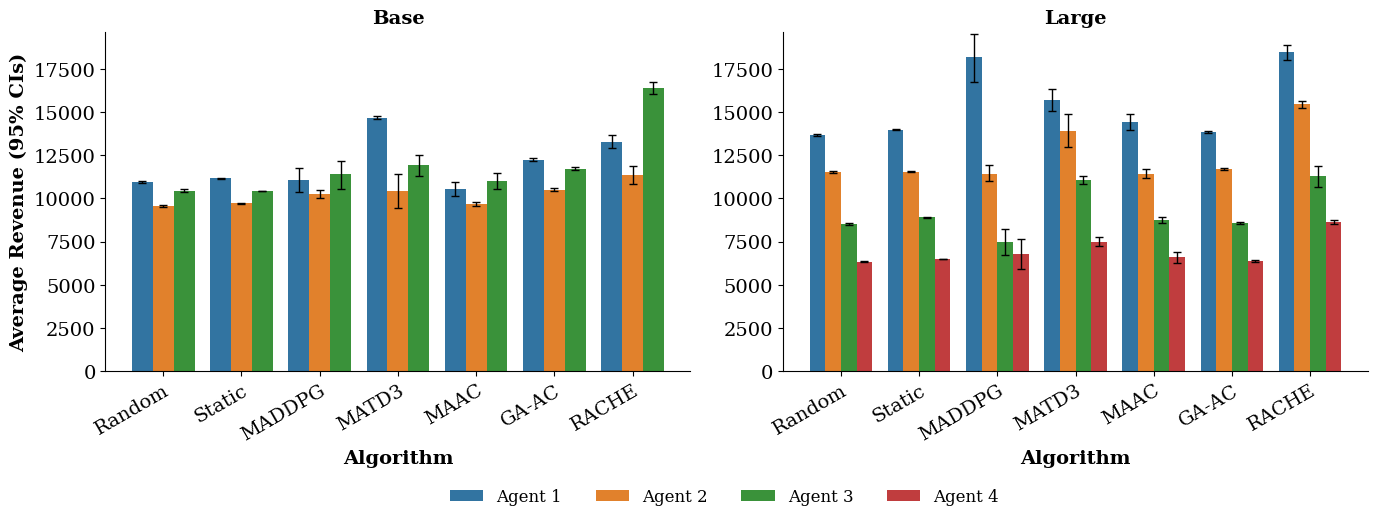

In [61]:
plot_per_agent_results(df_results, filename='revenue_per_agent', ylabel='Revenue', ymax=[19_650, 19_650], title=['Base', 'Large'])

### Probability of Improvement

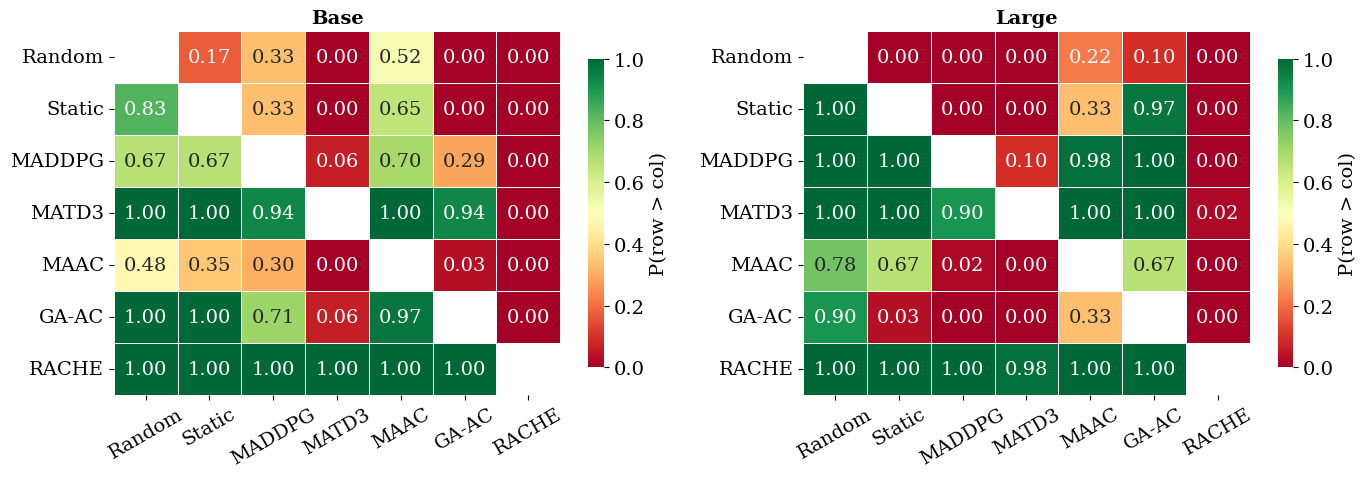

In [62]:
algorithms_poi = ['Random', 'Static', 'MADDPG', 'MATD3', 'MAAC', 'GA-AC', 'RACHE']
plot_poi_matrix(df_multi_segment_evaluation, df_extended_evaluation, tag='services/mean_total_profit', algorithms=algorithms_poi, filename='prob_improvement')

### Training learning curves

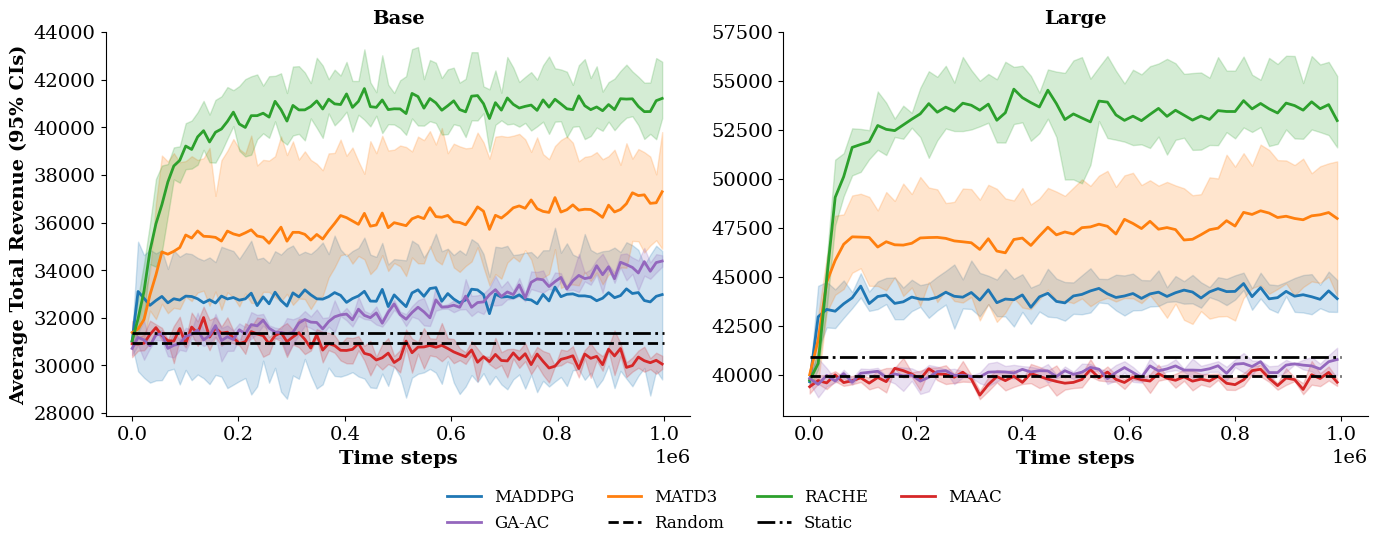

In [63]:
df_results = [df_multi_segment['services/mean_total_profit'], df_extended['services/mean_total_profit']]
plot_result(df_results, labels=algorithms, filename=f'training_curves', ylabel='Total Revenue', title=['Base', 'Large'], ymax=[44_000, 57_500], plot_random=True)

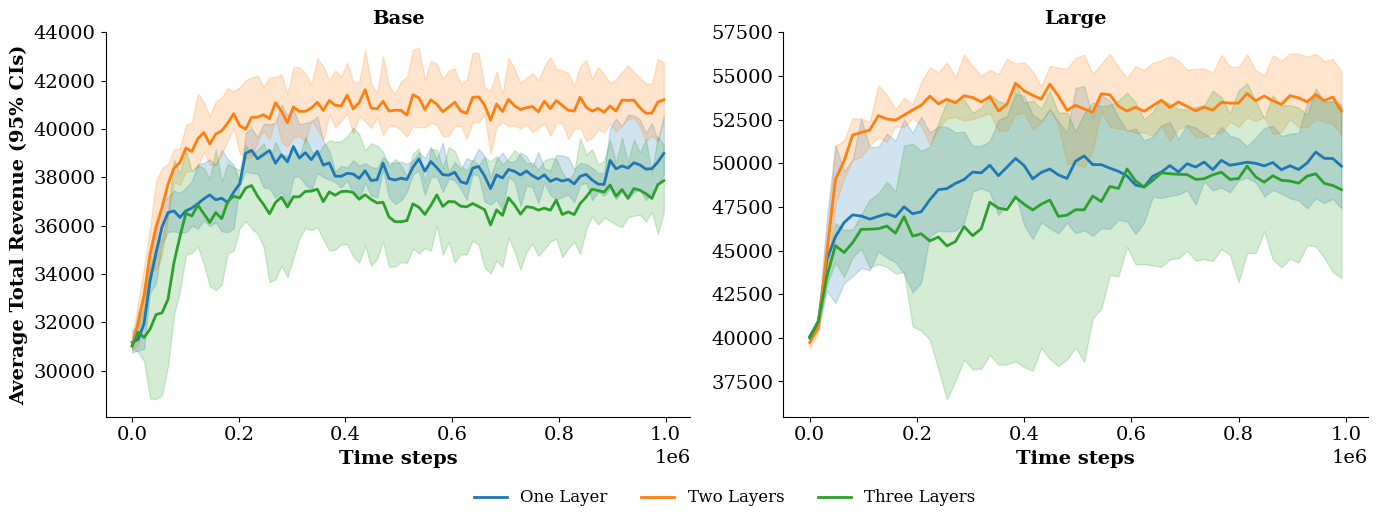

In [64]:
df_layers_results = [df_multi_segment_layers['services/mean_total_profit'], df_extended_layers['services/mean_total_profit']]
plot_result(df_layers_results, labels=['One Layer', 'Two Layers', 'Three Layers'], filename=f'layers_training_curves', ylabel='Total Revenue', title=['Base', 'Large'], ymax=[44_000, 57_500], plot_random=False)

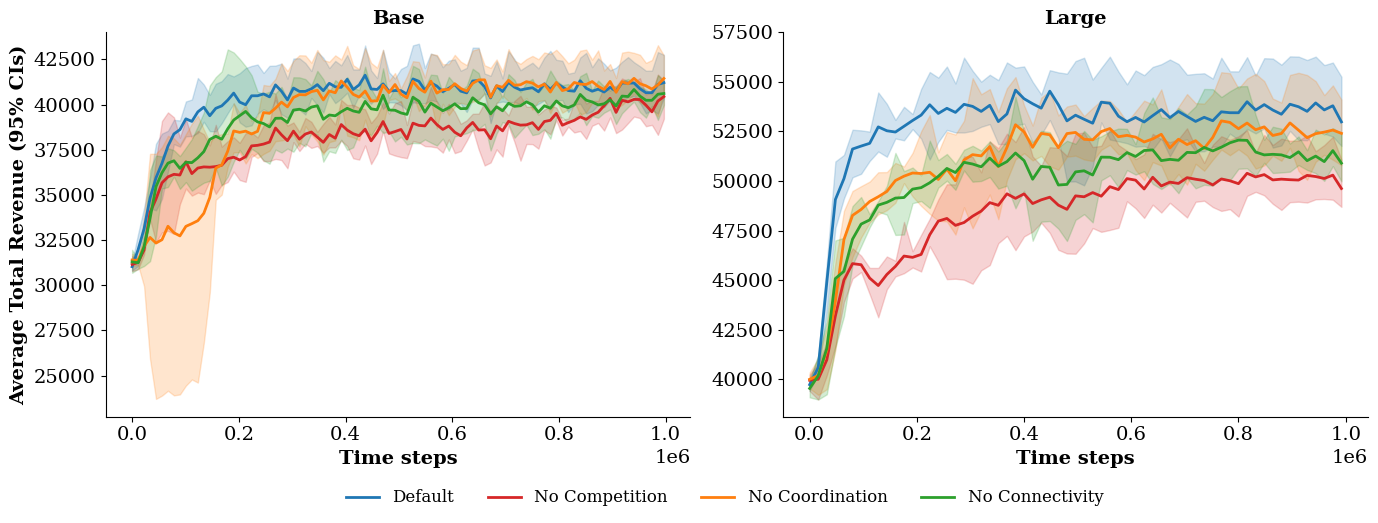

In [65]:
df_edges_results = [df_multi_segment_edges['services/mean_total_profit'], df_extended_edges['services/mean_total_profit']]
color_palette = sns.color_palette('tab10')
colors = [color_palette[0], color_palette[3], color_palette[1], color_palette[2]]
plot_result(df_edges_results, labels=['Default', 'No Competition', 'No Coordination', 'No Connectivity'], filename=f'edges_training_curves', ylabel='Total Revenue', title=['Base', 'Large'], ymax=[44_000, 57_500], plot_random=False, colors=colors)

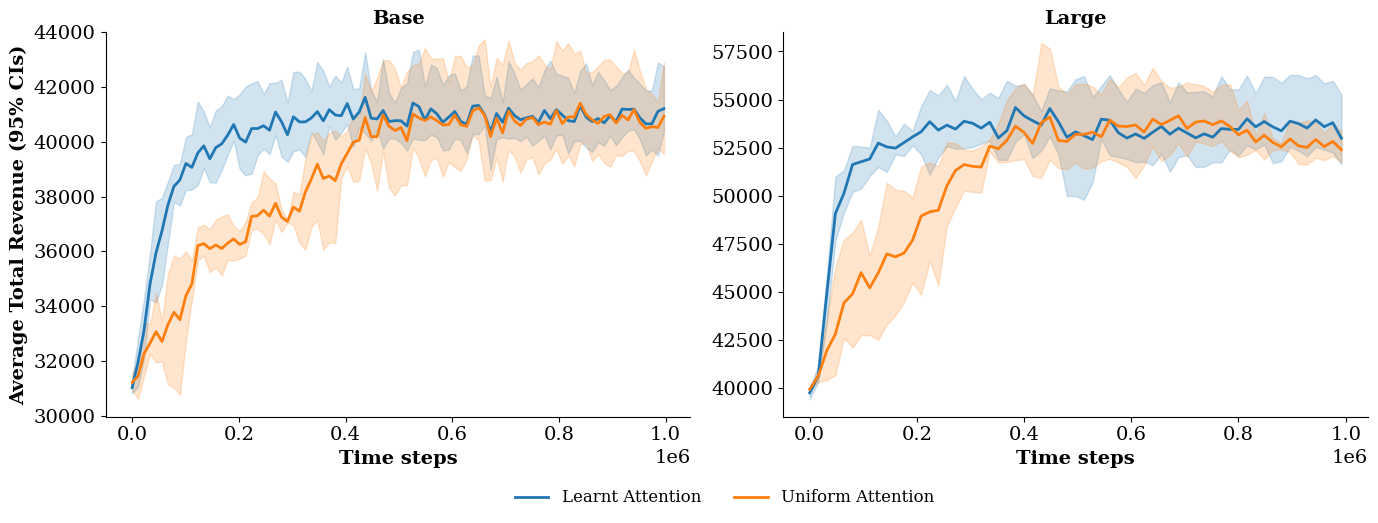

In [66]:
df_attention_results = [df_multi_segment_attention['services/mean_total_profit'], df_extended_attention['services/mean_total_profit']]
plot_result(df_attention_results, labels=['Learnt Attention', 'Uniform Attention'], filename=f'attention_training_curves', ylabel='Total Revenue', title=['Base', 'Large'], ymax=[44_000, 58_500], plot_random=False)

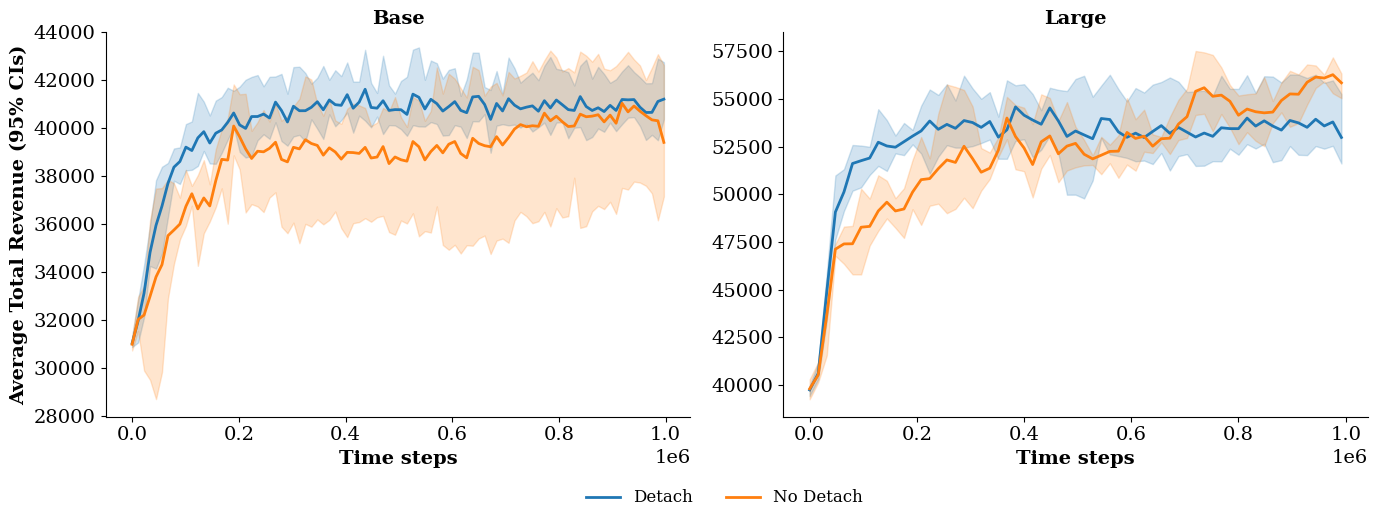

In [67]:
df_detach_results = [df_multi_segment_detach['services/mean_total_profit'], df_extended_detach['services/mean_total_profit']]
plot_result(df_detach_results, labels=['Detach', 'No Detach'], filename=f'detach_training_curves', ylabel='Total Revenue', title=['Base', 'Large'], ymax=[44_000, 58_500], plot_random=False)

In [68]:
get_std_diff(df_multi_segment_detach, ['Detach', 'No Detach'])

,mean,std
Detach (Agent 1),455.694658,70.742259
No Detach (Agent 1),498.907545,144.041844
Detach (Agent 2),363.942533,215.479409
No Detach (Agent 2),441.171874,13.626941
Detach (Agent 3),521.723108,39.155872
No Detach (Agent 3),537.063455,100.908622


In [69]:
get_std_diff(df_extended_detach, ['Detach', 'No Detach'])

,mean,std
Detach (Agent 1),666.358909,114.031911
No Detach (Agent 1),846.129931,195.344495
Detach (Agent 2),622.378080,61.760615
No Detach (Agent 2),943.659710,17.294612
Detach (Agent 3),450.691886,50.549108
No Detach (Agent 3),649.295362,61.145458
Detach (Agent 4),356.148547,37.731743
No Detach (Agent 4),535.944468,106.090816


### Attention

In [70]:
def plot_attention_evolution_heatmap(df_images_list, filename, num_agents=3):
    """
    Plot evolution of attention weights as a heatmap over training steps.
    """
    # Create subplots: 1 row x num_agents columns
    fig, axes = plt.subplots(1, num_agents, figsize=(15, 6), squeeze=False)
    axes = axes.flatten()
    
    for agent_idx in range(num_agents):
        tag = f'attention_heatmap/agent_{agent_idx}'
        df = df_images_list[tag][0]
        
        # Get all unique steps sorted
        steps = sorted(df['step'].unique())
        
        # Extract attention values for each step (averaged across executions)
        attention_over_time = []
        for step in steps:
            step_imgs = df[df['step'] == step]['image'].values
            step_img_avg = np.mean([img for img in step_imgs], axis=0)
            # Flatten to 1D (grayscale image, just take first channel or average)
            step_img_avg = step_img_avg.mean(axis=2).flatten()
            attention_over_time.append(step_img_avg)
        
        attention_over_time = np.array(attention_over_time).T  # Shape: [num_services, num_steps]
        # Normalize to [0, 1]
        attention_over_time = attention_over_time / 255.0
        
        # Plot as heatmap with normalized colorbar (0-1 for all subplots)
        im = axes[agent_idx].imshow(attention_over_time, aspect='auto', 
                                    cmap='viridis', interpolation='nearest',
                                    vmin=0, vmax=1)
        
        # Formatting
        axes[agent_idx].set_title(f'Agent {agent_idx + 1}', fontweight='bold')
        axes[agent_idx].set_xlabel('Training Step', fontweight='bold')
        
        if agent_idx == 0:
            axes[agent_idx].set_ylabel('Service Index', fontweight='bold')
        
        # Set x-axis to show actual step values
        num_ticks = min(5, len(steps))
        tick_indices = np.linspace(0, len(steps)-1, num_ticks, dtype=int)
        axes[agent_idx].set_xticks(tick_indices)
        axes[agent_idx].set_xticklabels([f'{steps[i]//1000}k' for i in tick_indices])
        
        # Set y-axis to show service indices starting from S1
        num_services = attention_over_time.shape[0]
        axes[agent_idx].set_yticks(range(num_services))
        axes[agent_idx].set_yticklabels([f'S{i+1}' for i in range(num_services)])
        
        plt.colorbar(im, ax=axes[agent_idx], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.savefig(f'{REPORTS_PATH}/{filename}.pdf', format='pdf')
    plt.show()

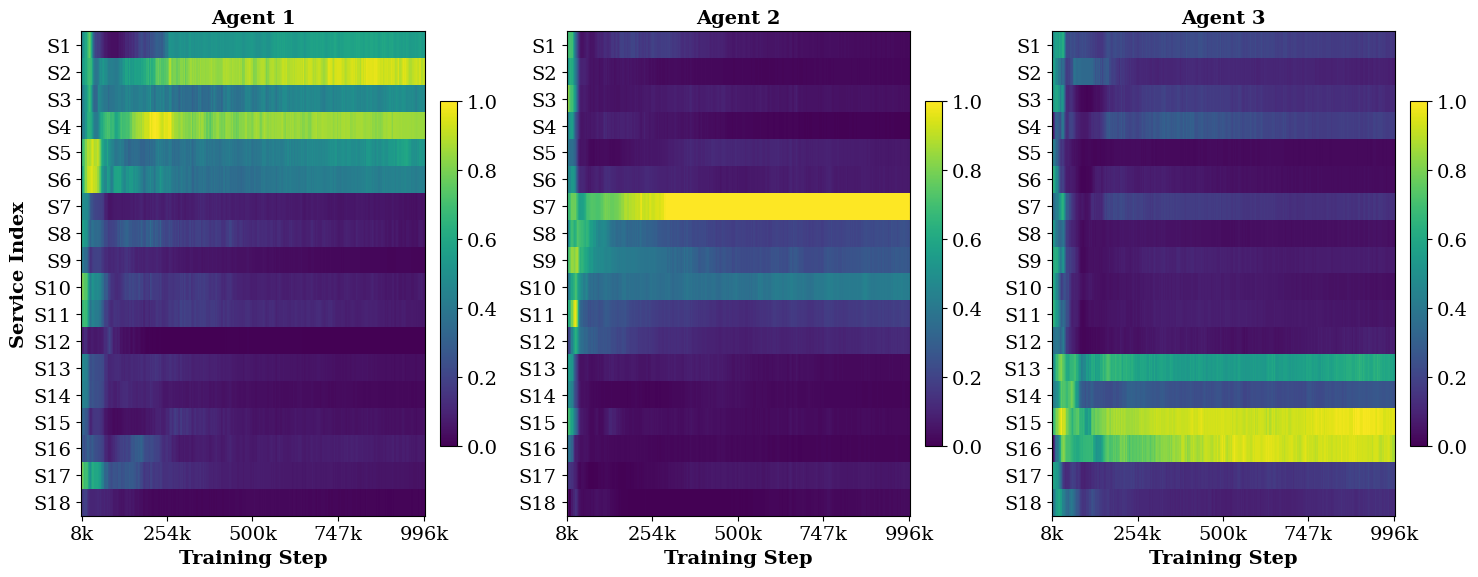

In [71]:
plot_attention_evolution_heatmap(df_multi_segment_images, 'multi_segment_attention', num_agents=3)

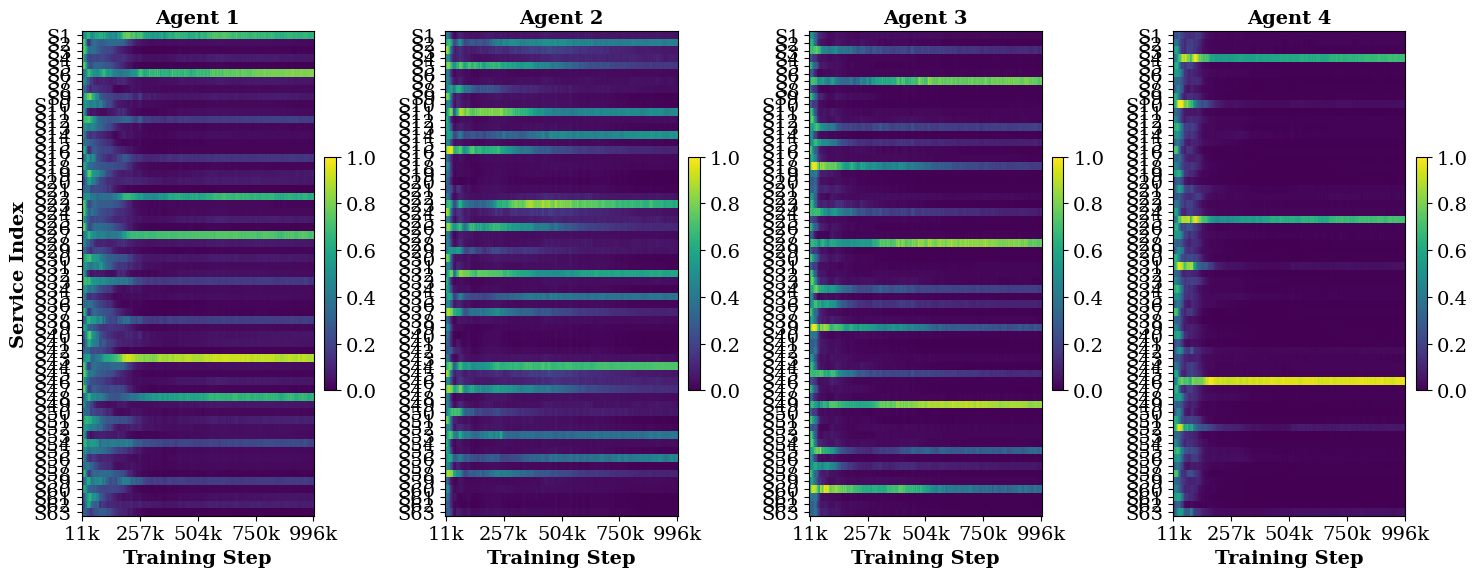

In [72]:
plot_attention_evolution_heatmap(df_extended_images, 'extended_attention', num_agents=4)

In [73]:
def plot_cross_agent_attention_matrix(df_images_list, envs, step, filename, titles):
    # Create heatmap
    fig, axs = plt.subplots(1, len(df_images_list), figsize=(11, 6))

    # Build cross-agent attention matrix from final step
    for i, (df_scenario, env, ax) in enumerate(zip(df_images_list, envs, axs)):
        service_to_agent_map = np.array([int(service.tsp.id) - 1 for service in env.kernel.supply.services])
        num_agents = num_agents = len(env.kernel.supply.tsps)
        cross_agent_matrix = np.zeros((num_agents, num_agents))

        for agent_idx in range(num_agents):
            tag = f'attention_heatmap/agent_{agent_idx}'
            df = df_scenario[tag][0]

            # Use specified step to extract attention values
            step_imgs = df[df['step'] == step]['image'].values
            step_img_avg = np.mean([img for img in step_imgs], axis=0)
            attention_vec = step_img_avg.mean(axis=2).flatten()  # Shape: [num_services]
            attention_vec = attention_vec / 255.0

            # Aggregate attention per target agent
            for target_agent in range(num_agents):
                target_service_indices = np.where(service_to_agent_map == target_agent)[0]
                if len(target_service_indices) > 0:
                    cross_agent_matrix[agent_idx, target_agent] = \
                        attention_vec[target_service_indices].mean()

        # Normalise each row to sum to 1.0
        row_sums = cross_agent_matrix.sum(axis=1, keepdims=True)
        cross_agent_matrix = np.where(row_sums > 0, cross_agent_matrix / row_sums, 0)

        # Plot as heatmap with normalized colorbar
        im = ax.imshow(cross_agent_matrix, cmap='viridis', aspect='auto', interpolation='nearest', vmin=0, vmax=1)

        # Set ticks and labels
        ax.set_xticks(range(num_agents))
        ax.set_yticks(range(num_agents))
        ax.set_xticklabels([f'A{i+1}' for i in range(num_agents)], fontweight='bold')
        ax.set_yticklabels([f'A{i+1}' for i in range(num_agents)], fontweight='bold')

        if i == 0:
            ax.set_ylabel('Source Agent', fontweight='bold')
        ax.set_xlabel('Target Agent', fontweight='bold')
        ax.set_title(titles[i], fontweight='bold')

        # Annotate cells with attention values
        for i in range(num_agents):
            for j in range(num_agents):
                ax.text(
                    j, i, f'{cross_agent_matrix[i, j]:.3f}', ha='center', va='center',
                    color='black' if cross_agent_matrix[i, j] > 0.5 else 'white', fontweight='bold'
                )

    plt.tight_layout()
    last_ax = axs[-1]
    pos = last_ax.get_position()
    cbar_width = 0.015
    cbar_gap = 0.01
    cax = fig.add_axes([pos.x1 + cbar_gap, pos.y0, cbar_width, pos.height])
    fig.colorbar(im, cax=cax, label='Attention')
    plt.savefig(f'{REPORTS_PATH}/{filename}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

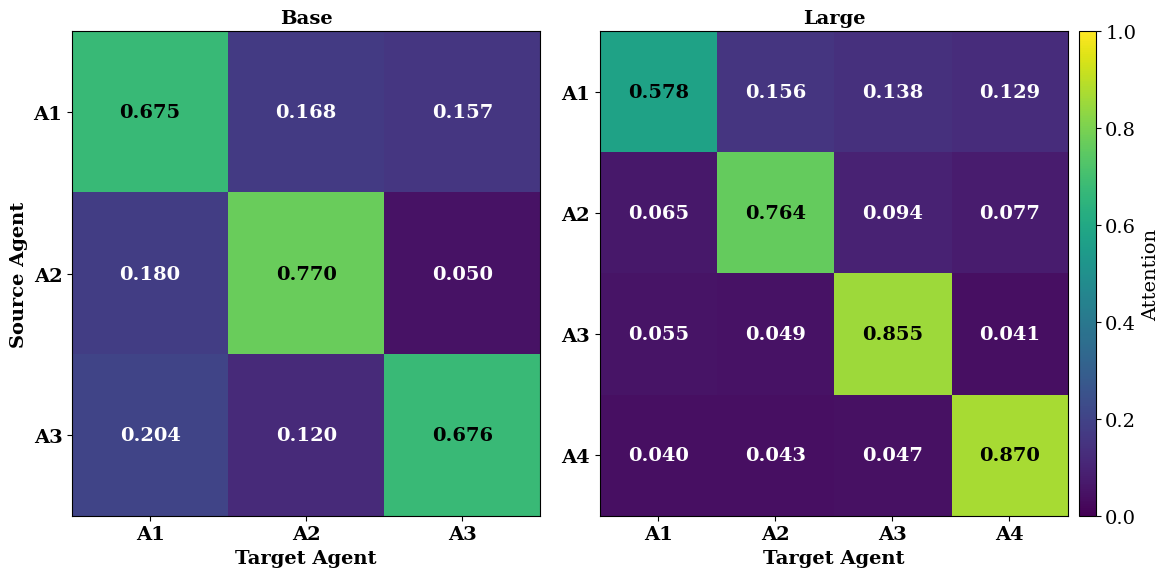

In [74]:
from robin.rl.entities import RobinEnvFactory

envs = [
    RobinEnvFactory.create(path_config_supply=MULTI_SEGMENT_CONFIG_SUPPLY, path_config_demand=MULTI_SEGMENT_CONFIG_DEMAND, multi_agent=True),
    RobinEnvFactory.create(path_config_supply=EXTENDED_CONFIG_SUPPLY, path_config_demand=EXTENDED_CONFIG_DEMAND, multi_agent=True)
]
step = 200_000
df_images = [df_multi_segment_images, df_extended_images]
plot_cross_agent_attention_matrix(df_images, envs, step, 'cross_attention', titles=['Base', 'Large'])

### Price changes

In [75]:
def load_initial_prices(config_path: str) -> dict[str, float]:
    """Return {service_id}/{origin}_{destination}/{seat_name} -> initial listed price from a supply config YAML."""
    with open(config_path) as f:
        config = yaml.safe_load(f)
    seat_names = {seat['id']: seat['name'] for seat in config['seat']}
    prices = {}
    for service in config['service']:
        odt = service['origin_destination_tuples'][0]
        origin, destination = odt['origin'], odt['destination']
        for seat in odt['seats']:
            seat_name = seat_names[seat['seat']]
            key = f"{service['id']}/{origin}_{destination}/{seat_name}"
            prices[key] = seat['price']
    return prices

In [76]:
SEEDS = [0, 41, 73]
ALGO_FOLDER = {'MADDPG': 'maddpg', 'MATD3': 'matd3', 'MAAC': 'maac', 'GA-AC': 'gaac', 'RACHE': 'graph_matd3'}

def evaluation_logs(model_dir: str, algorithms: list[str]) -> list[list[str]]:
    return [[f'{model_dir}/{ALGO_FOLDER[algo]}/{seed}/**/evaluation/events.out.tfevents.*' for seed in SEEDS] for algo in algorithms]

def load_final_prices(logs: list[list[str]], algorithms: list[str]) -> dict[str, dict[str, float]]:
    """Converged services/mean_last_prices/* per algorithm, via load_statistics_from_tensorboard.

    Reshapes the shared loader's positional per-tag lists into an algorithm-keyed dict and reduces
    each series to the converged value: the max-step row per seed (execution_num), averaged over seeds.
    """
    prefix = 'services/mean_last_prices/'
    df_metrics = load_statistics_from_tensorboard(logs, [re.escape(prefix) + '.*'], evaluation=True)
    final_prices = {algo: {} for algo in algorithms}
    for tag, per_algo in df_metrics.items():
        suffix = tag[len(prefix):]
        for algo, df in zip(algorithms, per_algo):
            per_seed = df.sort_values('step').groupby('execution_num', sort=False).tail(1)['value']
            final_prices[algo][suffix] = float(per_seed.mean())
    return final_prices

In [77]:
def build_price_change_df(final_prices_by_algo: dict[str, dict[str, float]], methods: list[str], initial_prices: dict[str, float], scenario: str) -> pd.DataFrame:
    rows = []
    for method in methods:
        final_prices = final_prices_by_algo[method]
        missing = set(initial_prices) - set(final_prices)
        for key, initial in initial_prices.items():
            service_id, od, seat = key.split('/')
            final = final_prices[key]
            pct_change = 100 * (final - initial) / initial
            rows.append({
                'scenario': scenario,
                'method': method,
                'service_id': service_id,
                'od': od,
                'seat': seat,
                'initial': initial,
                'final': final,
                'pct_change': pct_change
            })
    return pd.DataFrame(rows)

In [78]:
def plot_price_changes(df_prices: pd.DataFrame, methods: list[str], filename: str = 'price_changes') -> None:
    fig, axs = plt.subplots(ncols=2, figsize=(14, 5))
    scenarios = ['Base', 'Large']
    seat_order = ['Basic', 'Premium']

    for i, (ax, scenario) in enumerate(zip(axs, scenarios)):
        data = df_prices[df_prices['scenario'] == scenario]
        sns.boxplot(x='method', y='pct_change', hue='seat', data=data, ax=ax, order=methods, hue_order=seat_order, linewidth=1.5, medianprops={'color': 'red'})
        ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=0)
        ax.spines[['right', 'top']].set_visible(False)
        ax.set_xlabel('Algorithm', fontweight='bold')
        ax.set_title(scenario, fontweight='bold')
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
        ax.get_legend().remove()

    axs[0].set_ylabel('Final Price Change (%)', fontweight='bold')
    axs[1].set_ylabel('')

    plt.tight_layout()
    handles, labels = axs[0].get_legend_handles_labels()
    plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(-0.10, -0.30), ncol=2, frameon=False)
    plt.savefig(f'{REPORTS_PATH}/{filename}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

In [79]:
initial_base = load_initial_prices(MULTI_SEGMENT_CONFIG_SUPPLY)
initial_large = load_initial_prices(EXTENDED_CONFIG_SUPPLY)

algorithms = ['MADDPG', 'MATD3', 'MAAC', 'GA-AC', 'RACHE']
final_prices_base = load_final_prices(evaluation_logs(f'{MODELS_PATH}/multi_segment_v3_rgcn_x2_1024_1M', algorithms), algorithms)
final_prices_large = load_final_prices(evaluation_logs(f'{MODELS_PATH}/extended_v2_rgcn_x2_1024_1M', algorithms), algorithms)

df_prices = pd.concat([
    build_price_change_df(final_prices_base, algorithms, initial_base, 'Base'),
    build_price_change_df(final_prices_large, algorithms, initial_large, 'Large'),
], ignore_index=True)

Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maddpg/0/290326-141135/evaluation/events.out.tfevents.1776153209.oreto.1563800.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maddpg/41/290326-161624/evaluation/events.out.tfevents.1776153742.oreto.1563978.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maddpg/73/290326-182109/evaluation/events.out.tfevents.1776154276.oreto.1564058.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/matd3/0/290326-040122/evaluation/events.out.tfevents.1776159940.oreto.1565807.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/matd3/41/290326-080426/evaluation/events.out.tfevents.1776161035.oreto.1566178.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/matd3/73/290326-120616/evaluation/events.out.tfevents.1776162129.oreto.1566589.0
Loading ../models/paper/multi_segment_v3_rgcn_x2_1024_1M/maac/0/150426-005659/evaluation/events.out.tfevents.1776422009.oreto
Loading ../models/paper/multi_segment_v3_rgcn

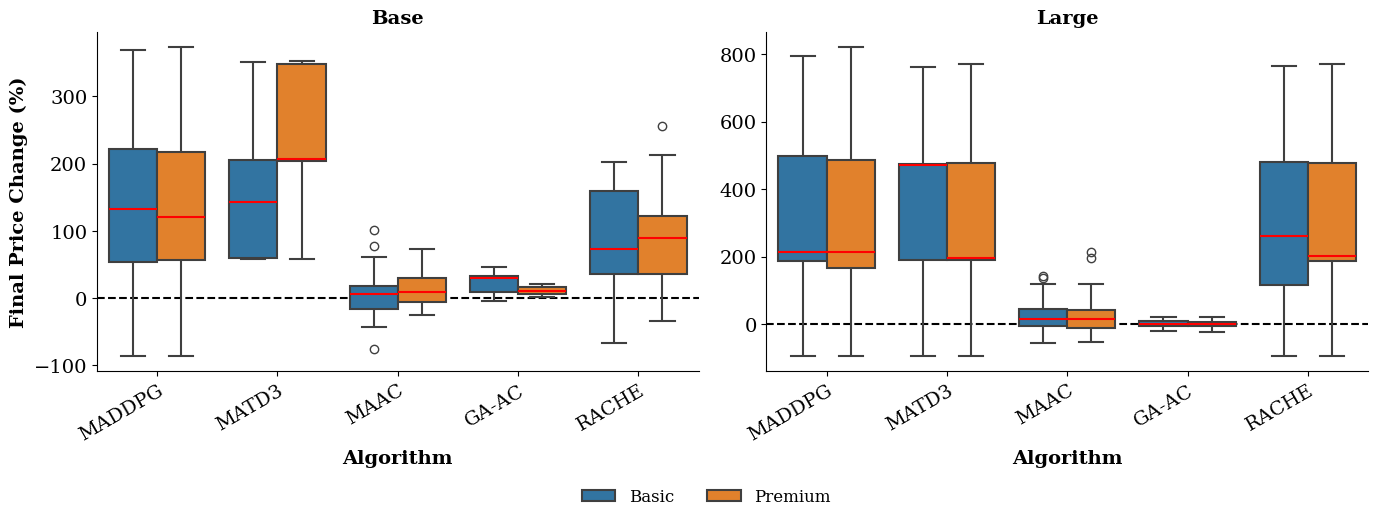

In [80]:
plot_price_changes(df_prices, algorithms, filename='price_changes')